<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/exercicio_arvore_matriz_confusao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios

## 1) Modificar a profundidade da árvore e comparar resultados
**Objetivo:**

Entender como a profundidade (max_depth) influencia o underfitting e o overfitting.

Altere o parâmetro da árvore de decisão:

model = DecisionTreeClassifier(max_depth=3)

E teste diferentes valores:

max_depth = 1;
max_depth = 5;
max_depth = None (profundidade ilimitada)

Para cada profundidade:

1. Treine o modelo.
2. Plote a árvore de decisão.
3. Gere a fronteira de decisão.
4. Calcule as métricas: accuracy, precisão, recall, F1.

**Pergunta final:** Como a profundidade influencia o overfitting e o desempenho no teste?

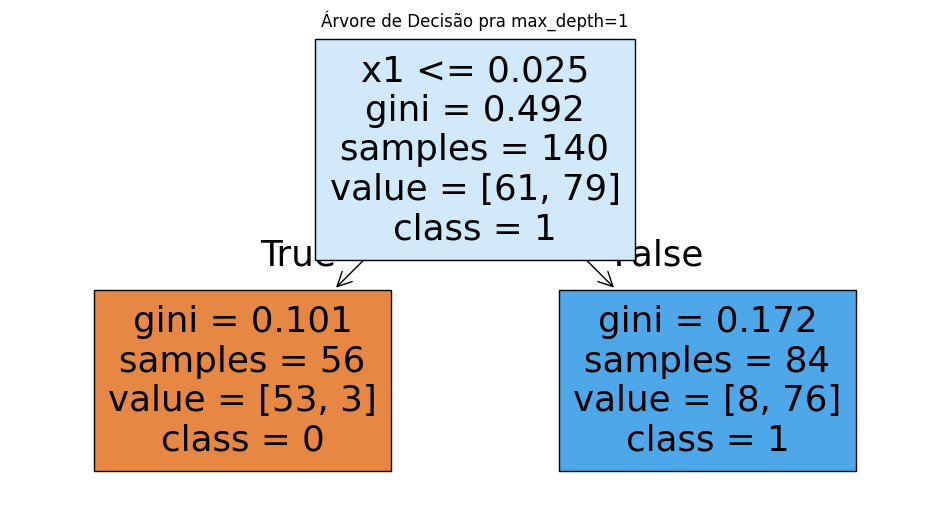

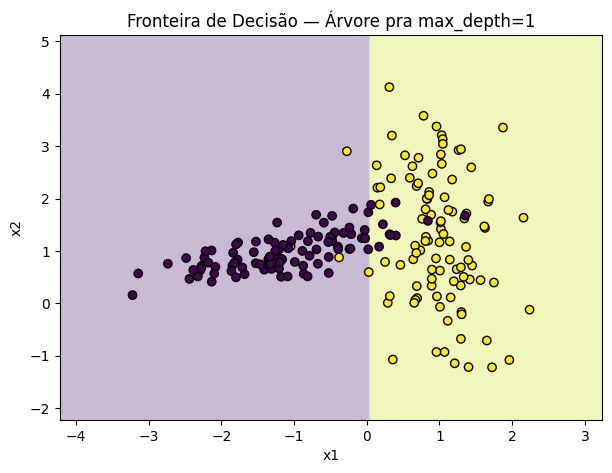

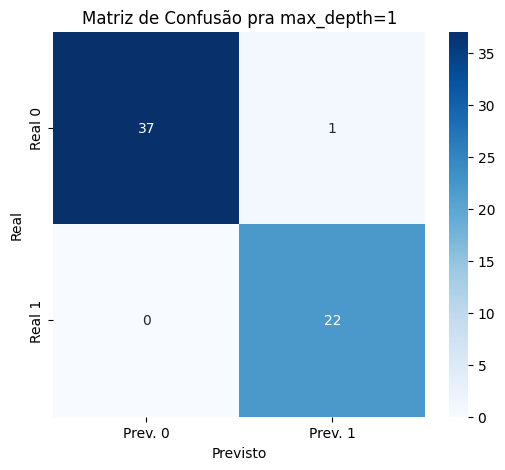

MÉTRICAS DO MODELO
Accuracy pra max_depth=1 : 0.983
Precisão pra max_depth=1 : 0.957
Recall pra max_depth=1   : 1.000
F1-score pra max_depth=1 : 0.978


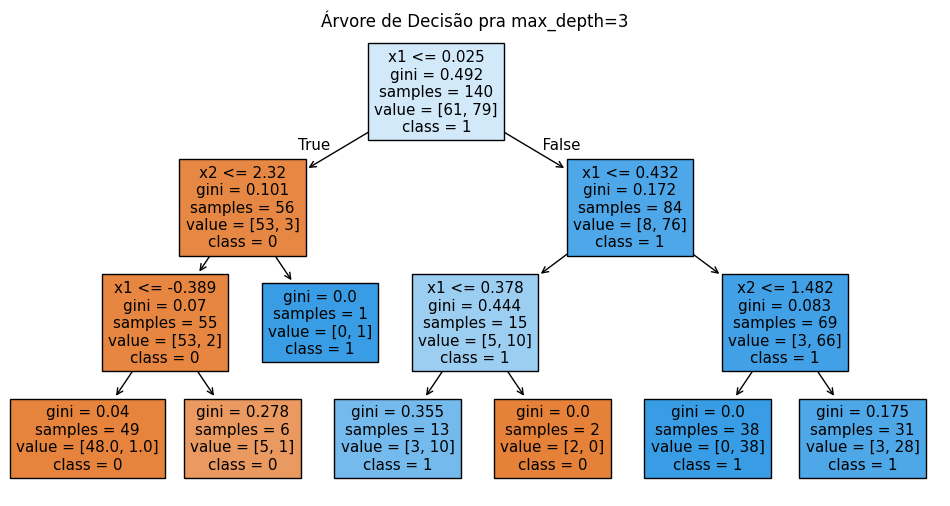

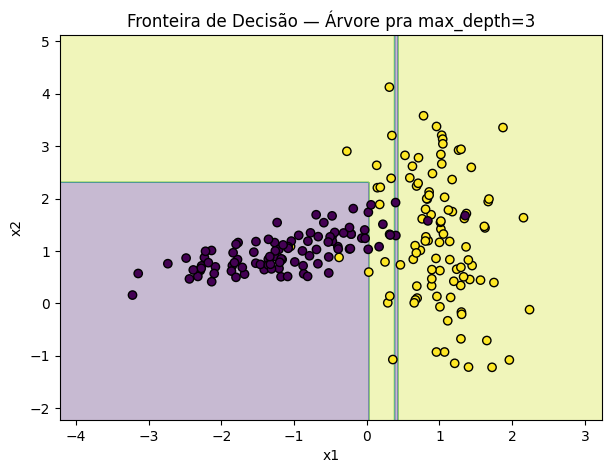

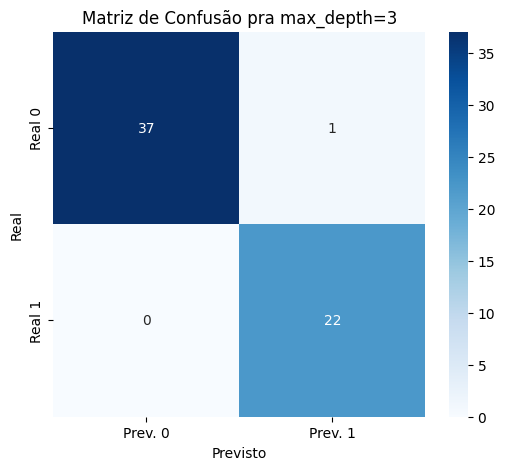

MÉTRICAS DO MODELO
Accuracy pra max_depth=3 : 0.983
Precisão pra max_depth=3 : 0.957
Recall pra max_depth=3   : 1.000
F1-score pra max_depth=3 : 0.978


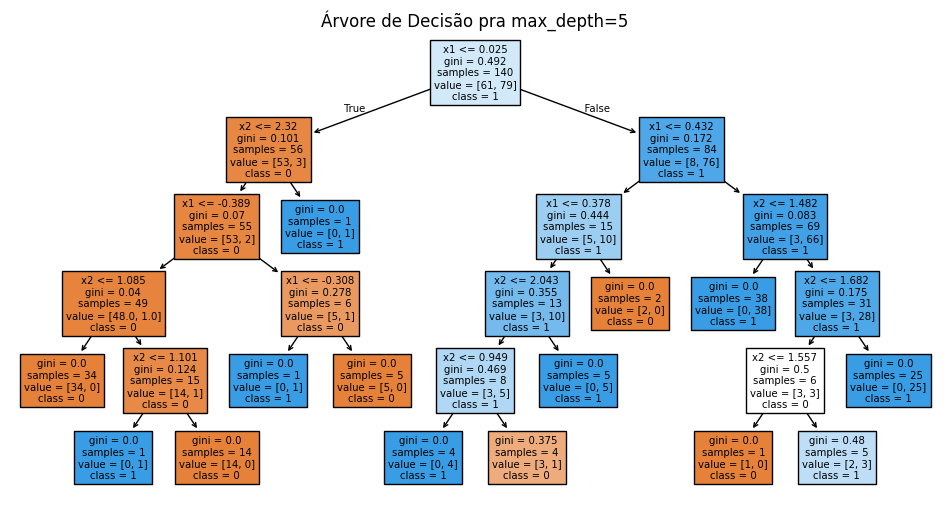

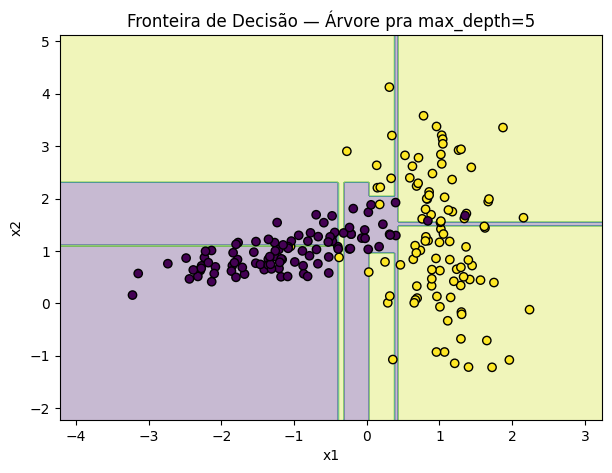

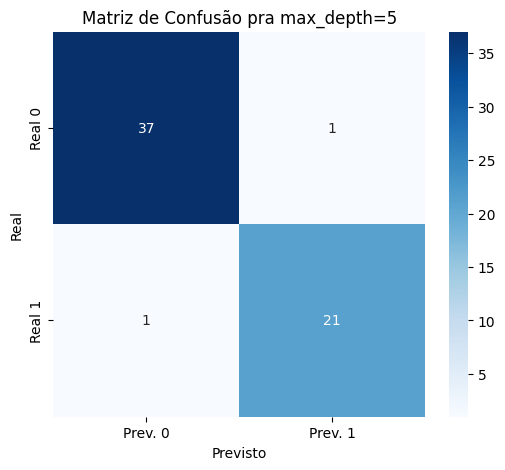

MÉTRICAS DO MODELO
Accuracy pra max_depth=5 : 0.967
Precisão pra max_depth=5 : 0.955
Recall pra max_depth=5   : 0.955
F1-score pra max_depth=5 : 0.955


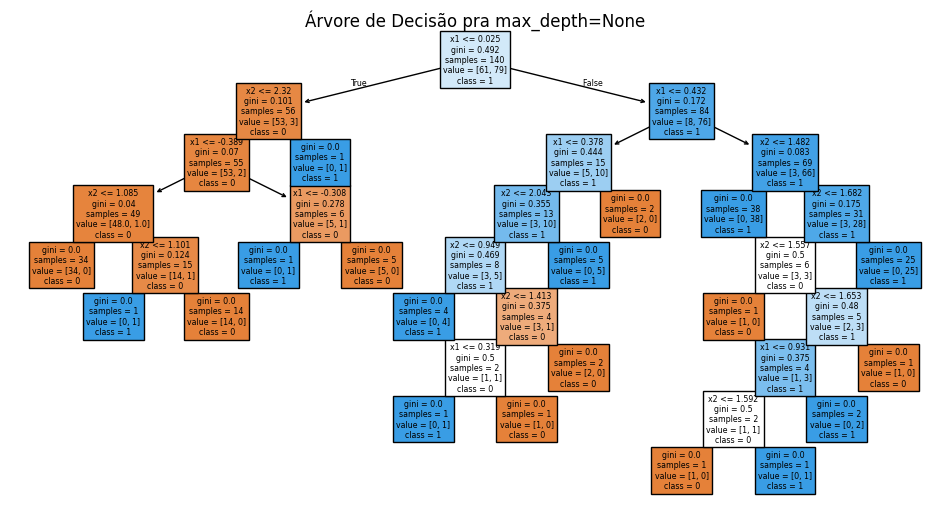

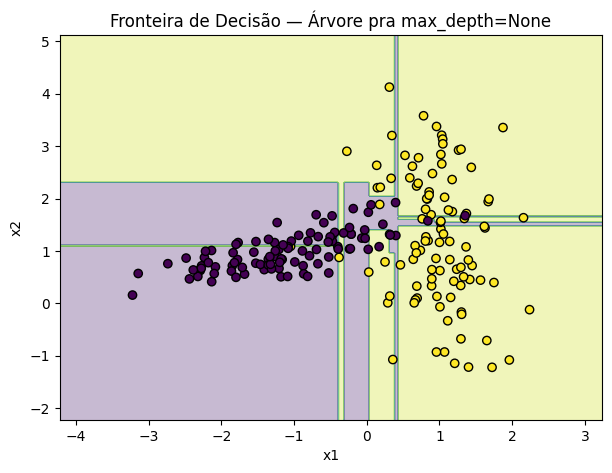

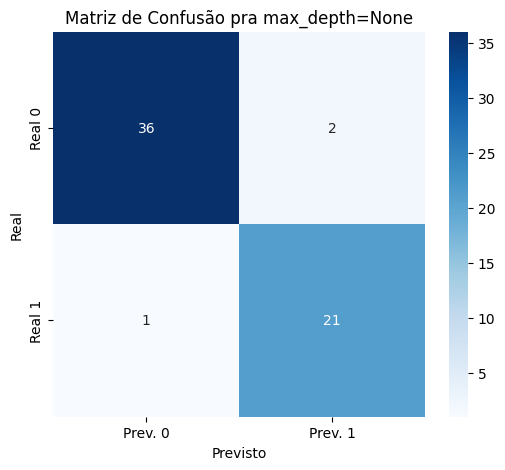

MÉTRICAS DO MODELO
Accuracy pra max_depth=None : 0.950
Precisão pra max_depth=None : 0.913
Recall pra max_depth=None   : 0.955
F1-score pra max_depth=None : 0.933


In [17]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# 1) Gerar dados simples (2 classes)
# =====================================================
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

# =====================================================
# 2) Dividir em treino e teste
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

md = [1, 3, 5, None] #max_depth

# =====================================================
# 3) Treinar a árvore
# =====================================================

for m in md:
  model = DecisionTreeClassifier(max_depth=m)
  model.fit(X_train, y_train)

  # =====================================================
  # 4) Visualizar a Árvore
  # =====================================================
  plt.figure(figsize=(12,6))
  plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
  plt.title(f"Árvore de Decisão pra max_depth={m}")
  plt.show()

  # =====================================================
  # 5) Fronteira de decisão
  # =====================================================
  xx, yy = np.meshgrid(
      np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
      np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
  )

  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(7,5))
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

  plt.title(f"Fronteira de Decisão — Árvore pra max_depth={m}")
  plt.xlabel("x1")
  plt.ylabel("x2")
  plt.show()

  # =====================================================
  # 6) Matriz de Confusão
  # =====================================================
  y_pred = model.predict(X_test)

  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=["Prev. 0", "Prev. 1"],
              yticklabels=["Real 0", "Real 1"])

  plt.title(f"Matriz de Confusão pra max_depth={m}")
  plt.ylabel("Real")
  plt.xlabel("Previsto")
  plt.show()

  # =====================================================
  # 7) Métricas de avaliação
  # =====================================================
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  print("MÉTRICAS DO MODELO")
  print(f"Accuracy pra max_depth={m} : {acc:.3f}")
  print(f"Precisão pra max_depth={m} : {prec:.3f}")
  print(f"Recall pra max_depth={m}   : {rec:.3f}")
  print(f"F1-score pra max_depth={m} : {f1:.3f}")


**Resposta**: quanto mais profundo é a arvóre, mais ela memoriza os dados de treinamento e maior risco de ter overffting, pois como mostrado na comparação do exercício, quanto mais a profundidade da arvóre aumentava, menor era o desempenho do modelo.

## 2) Alterar o dataset e reavaliar o modelo
**Objetivo:**

Explorar como diferentes distribuições de dados afetam o comportamento da árvore.

Modifique o bloco:

X, y = make_classification(...)

Testando diferentes configurações:

1. Aumente o ruído dos rótulos
flip_y=0.15
2. Aumente o número de clusters por classe
n_clusters_per_class=2
3. Aumente o número de features informativas
n_features=4
n_informative=4

Para cada cenário:

1. Refaça o treino.
2. Plote (quando possível).
3. Gere a matriz de confusão.
4. Calcule accuracy, precisão, recall e F1.

**Pergunta final:** Em quais condições o modelo piora mais? Por quê?

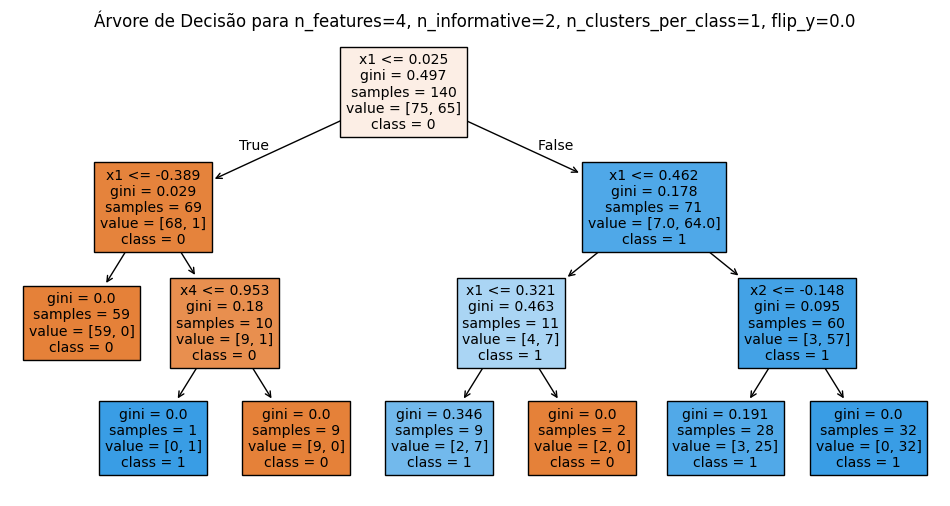

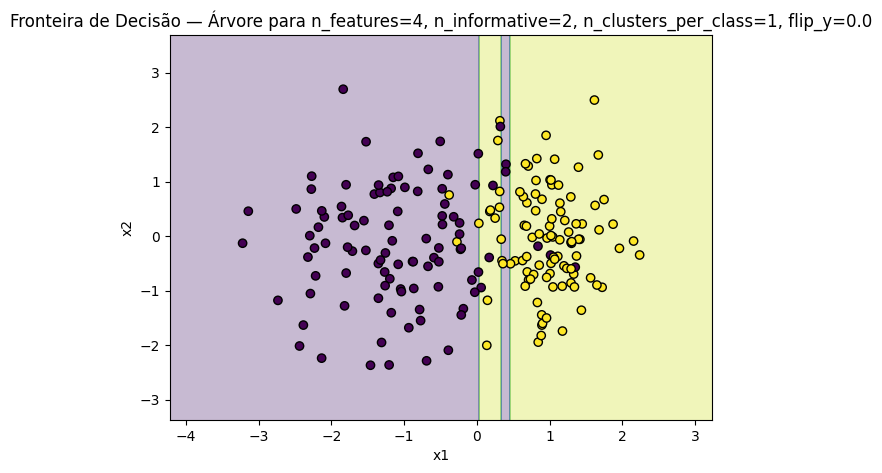

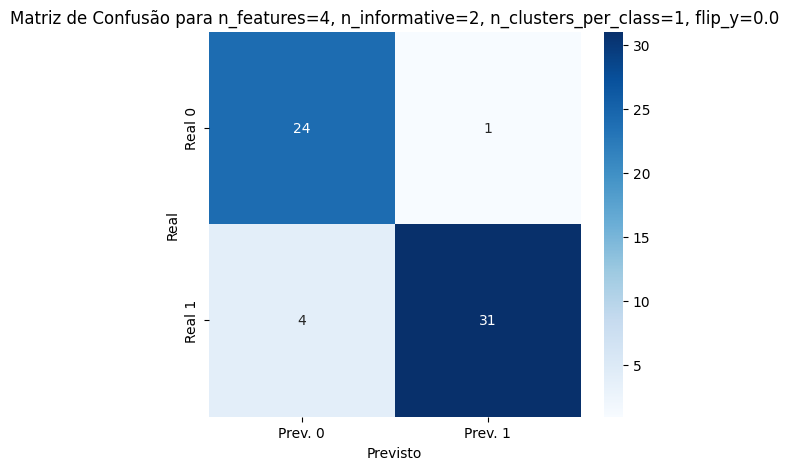

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.0 : 0.917
Precisão para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.0 : 0.969
Recall para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.0  : 0.886
F1-score para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.0 : 0.925


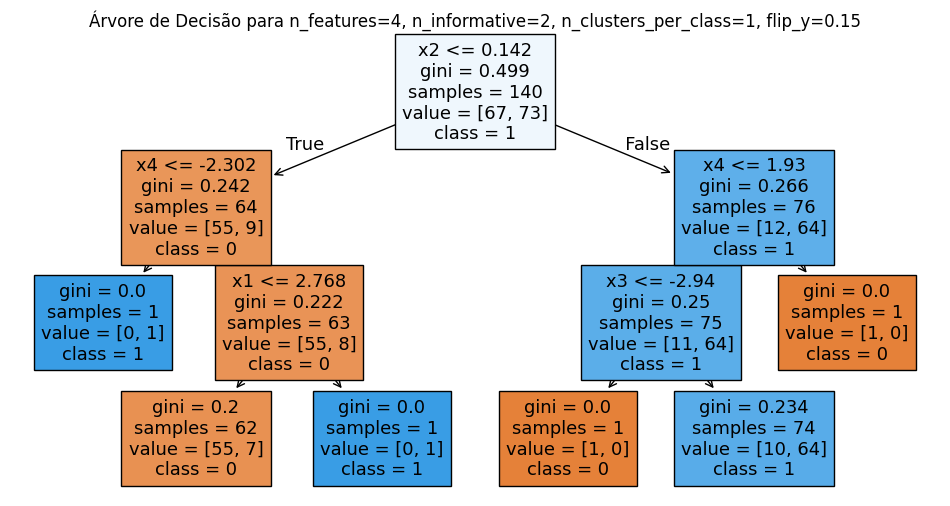

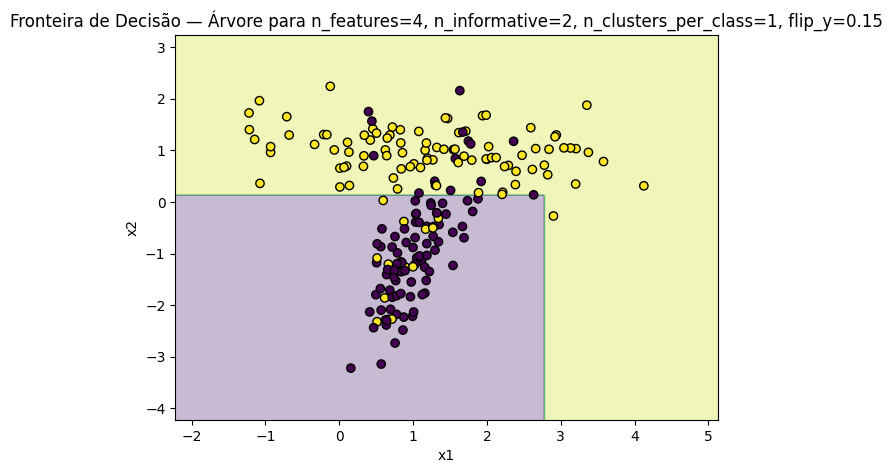

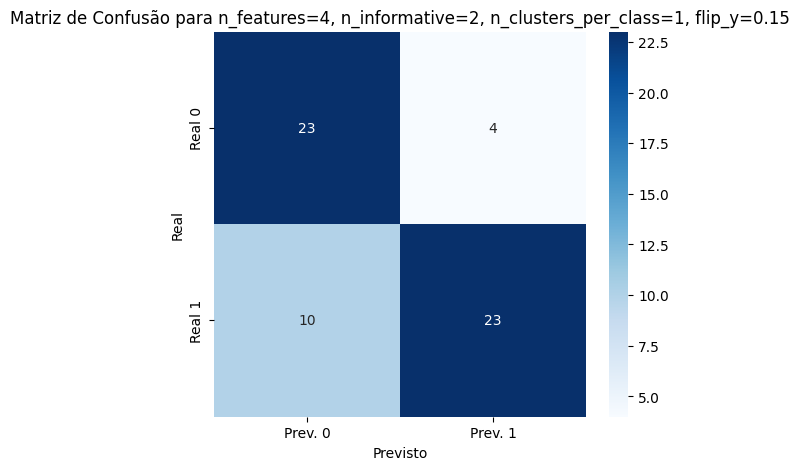

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.15 : 0.767
Precisão para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.15 : 0.852
Recall para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.15  : 0.697
F1-score para n_features=4, n_informative=2, n_clusters_per_class=1, flip_y=0.15 : 0.767


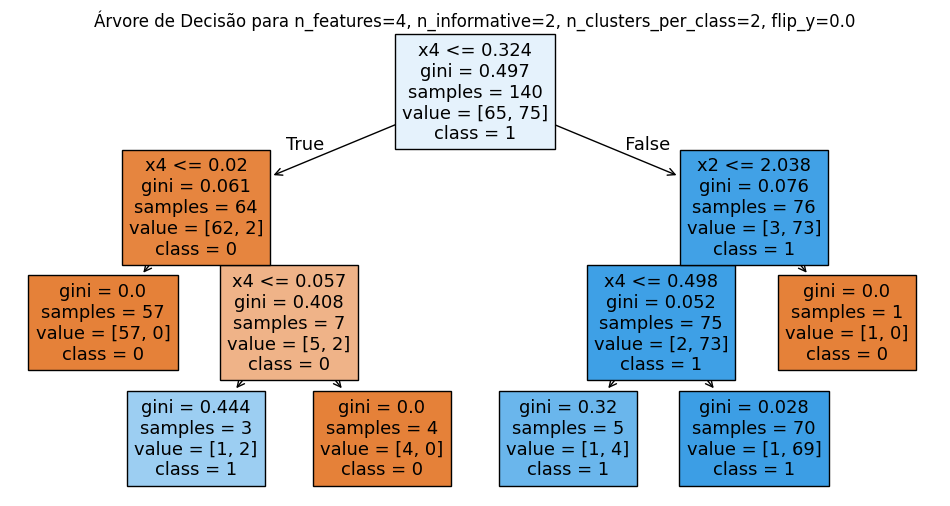

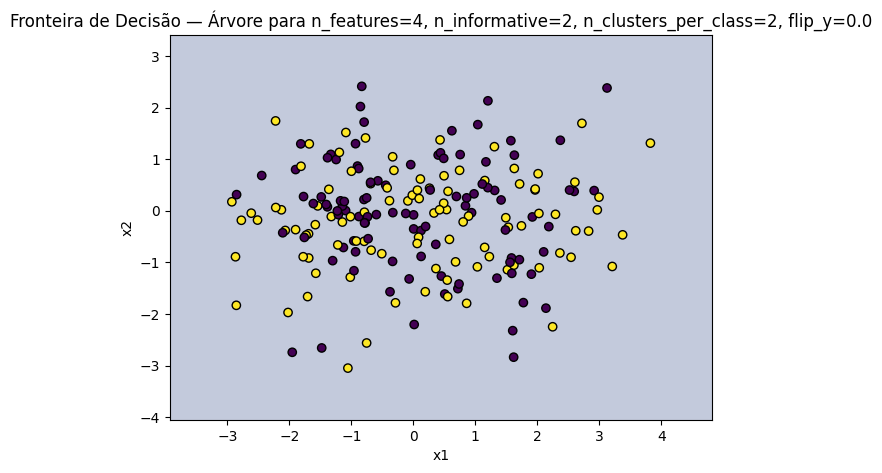

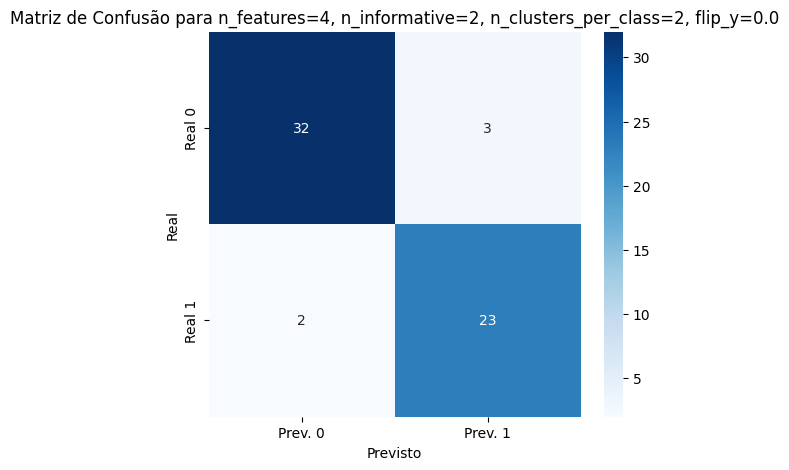

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.0 : 0.917
Precisão para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.0 : 0.885
Recall para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.0  : 0.920
F1-score para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.0 : 0.902


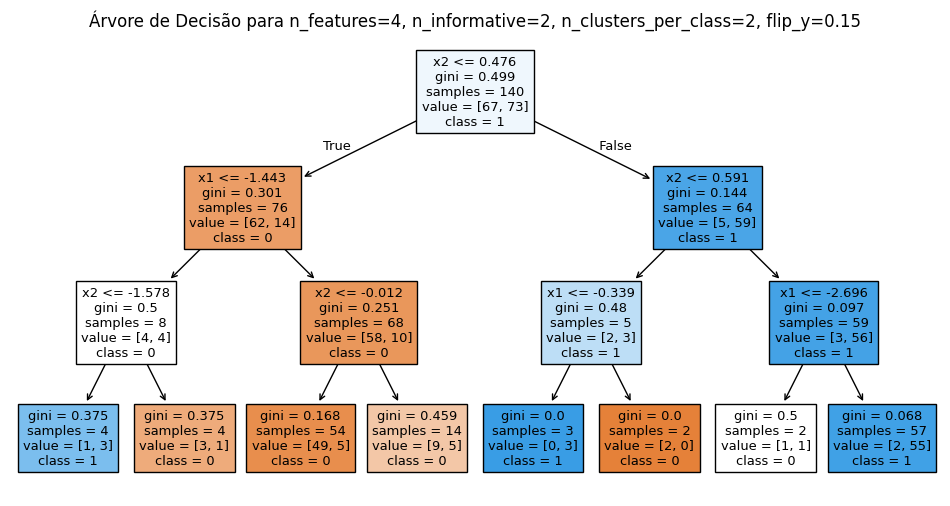

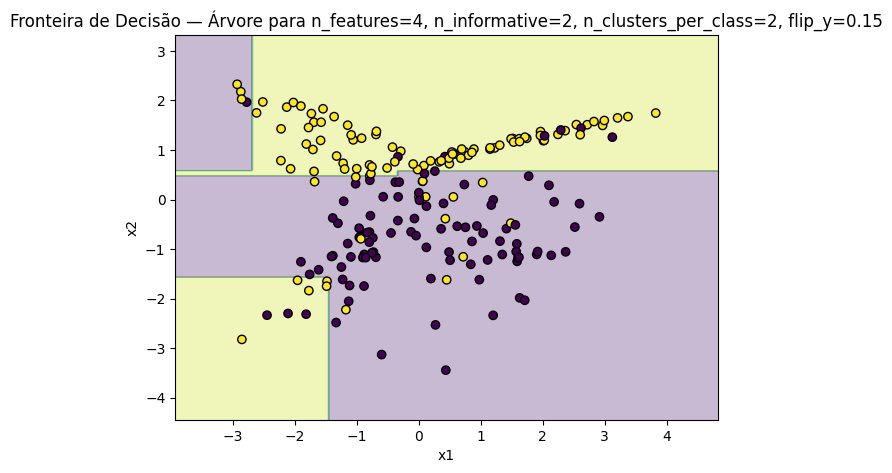

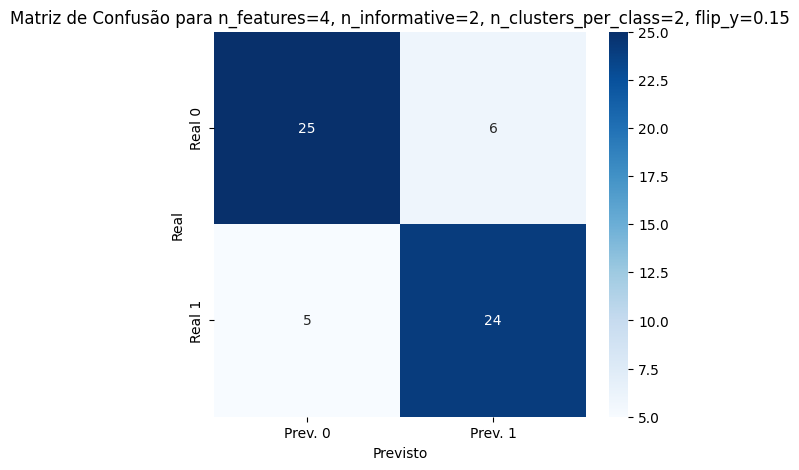

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.15 : 0.817
Precisão para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.15 : 0.800
Recall para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.15  : 0.828
F1-score para n_features=4, n_informative=2, n_clusters_per_class=2, flip_y=0.15 : 0.814


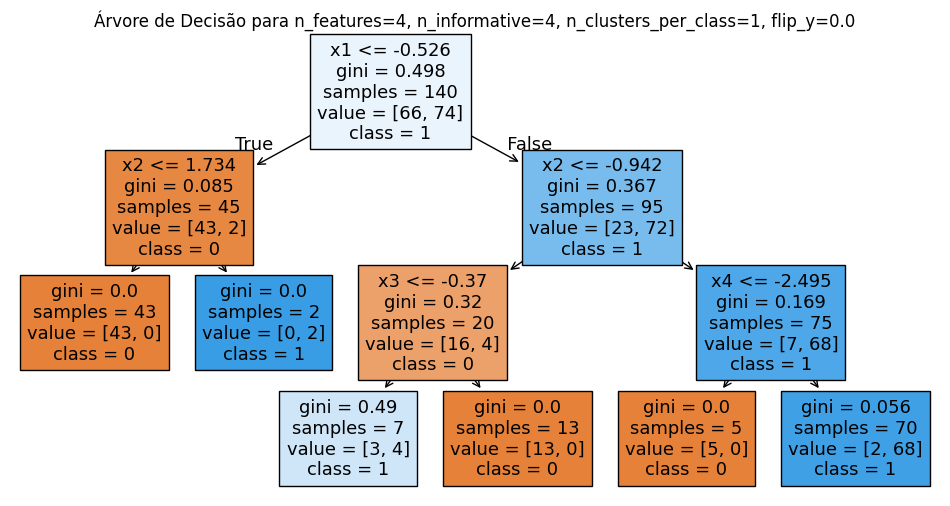

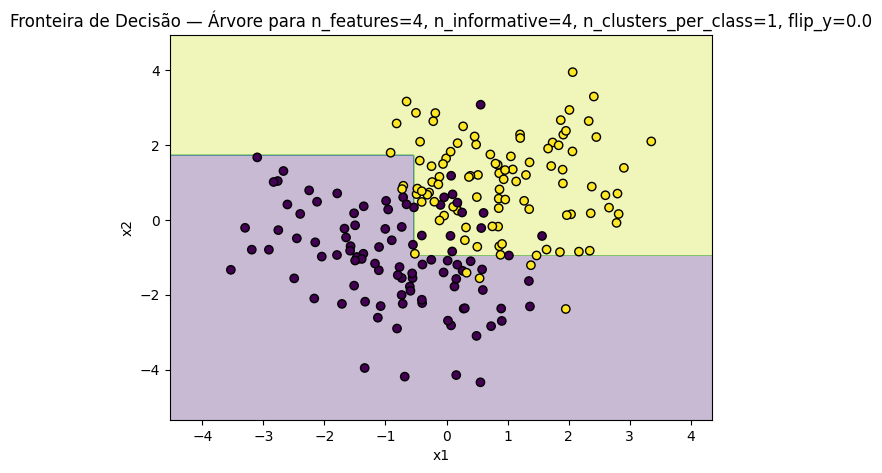

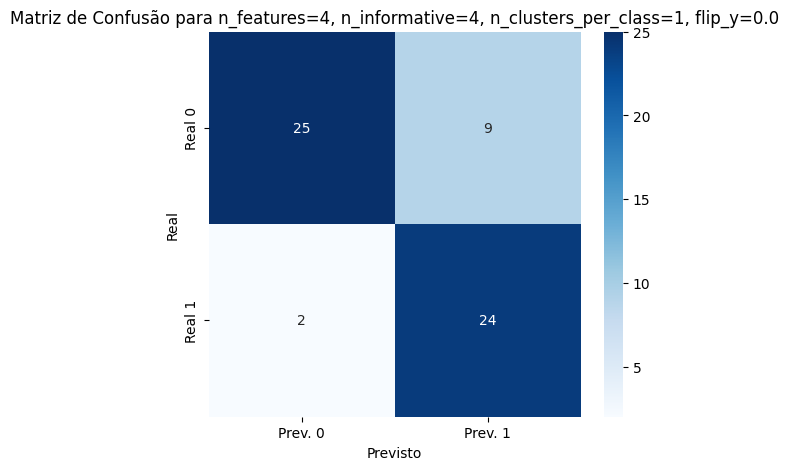

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.0 : 0.817
Precisão para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.0 : 0.727
Recall para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.0  : 0.923
F1-score para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.0 : 0.814


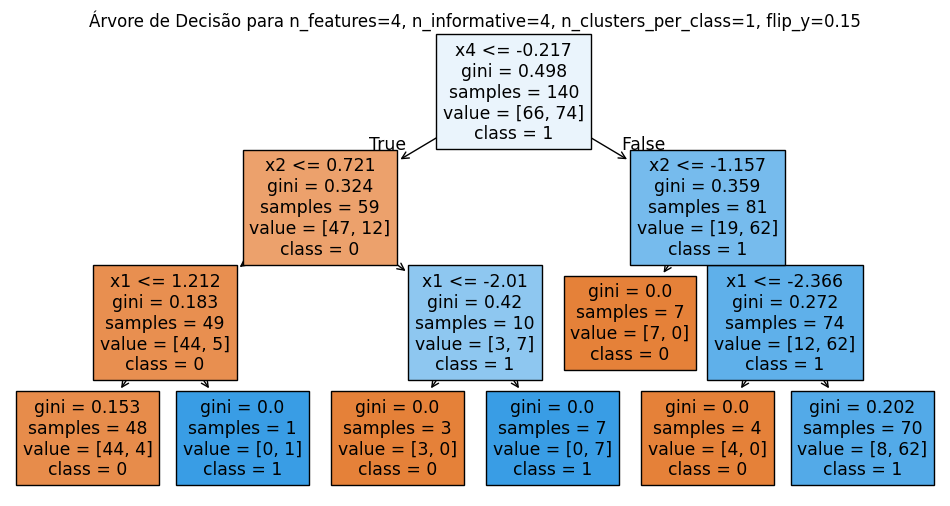

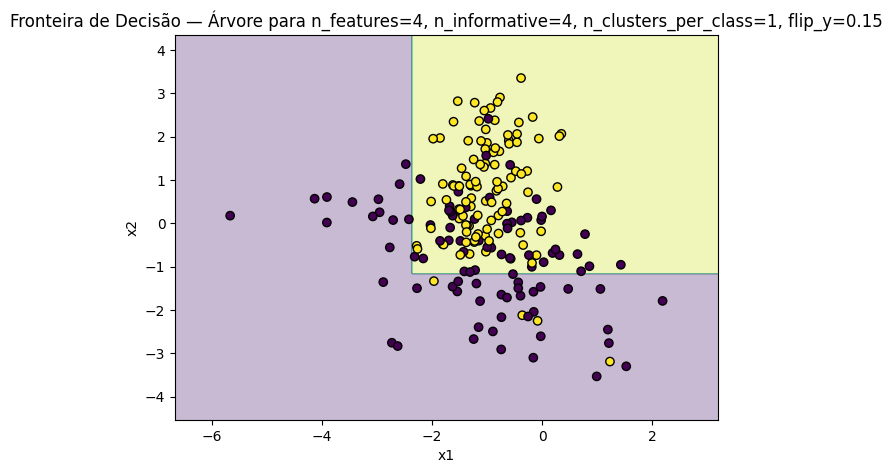

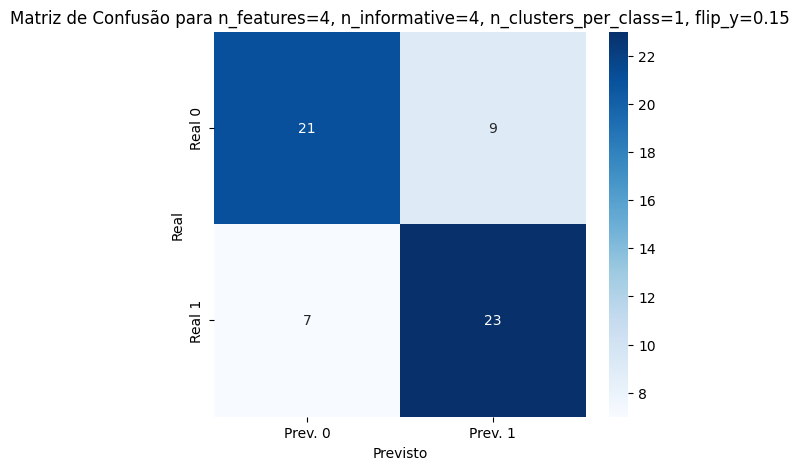

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.15 : 0.733
Precisão para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.15 : 0.719
Recall para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.15  : 0.767
F1-score para n_features=4, n_informative=4, n_clusters_per_class=1, flip_y=0.15 : 0.742


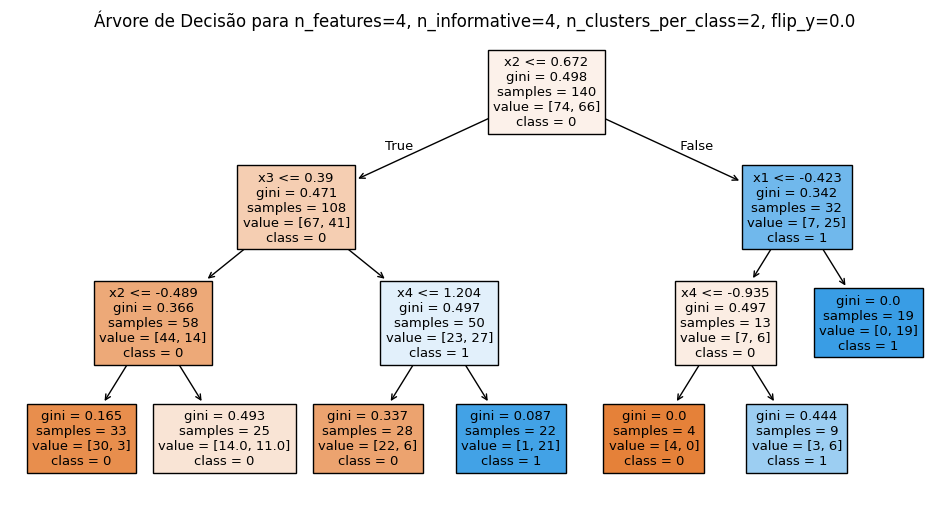

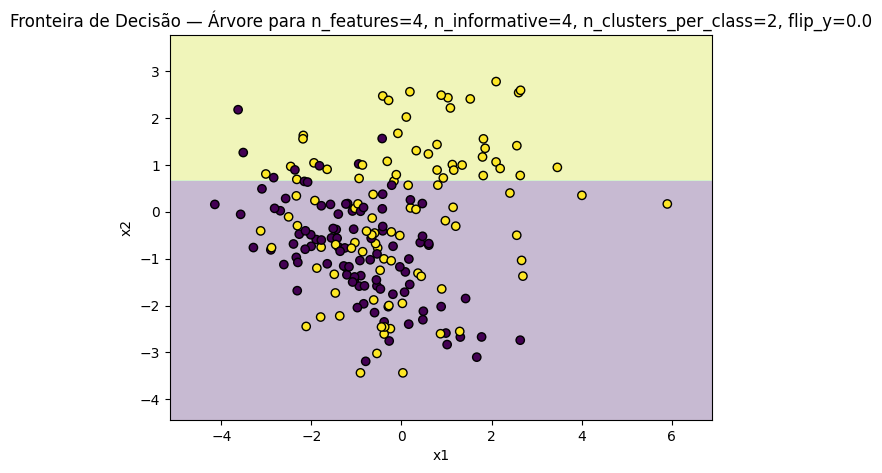

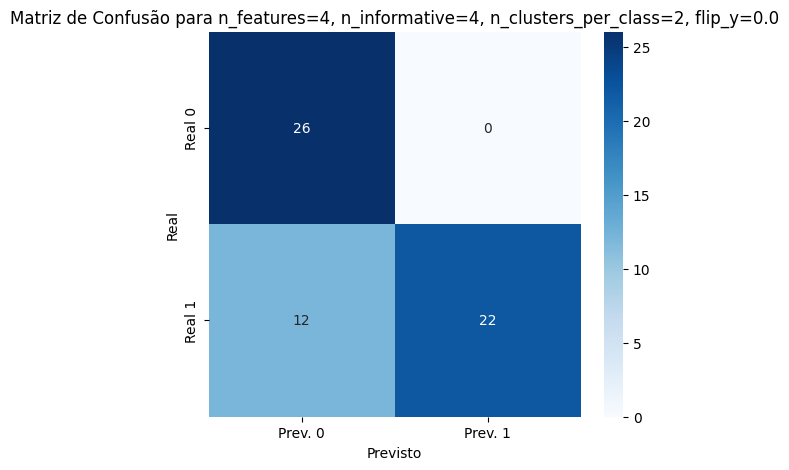

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.0 : 0.800
Precisão para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.0 : 1.000
Recall para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.0  : 0.647
F1-score para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.0 : 0.786


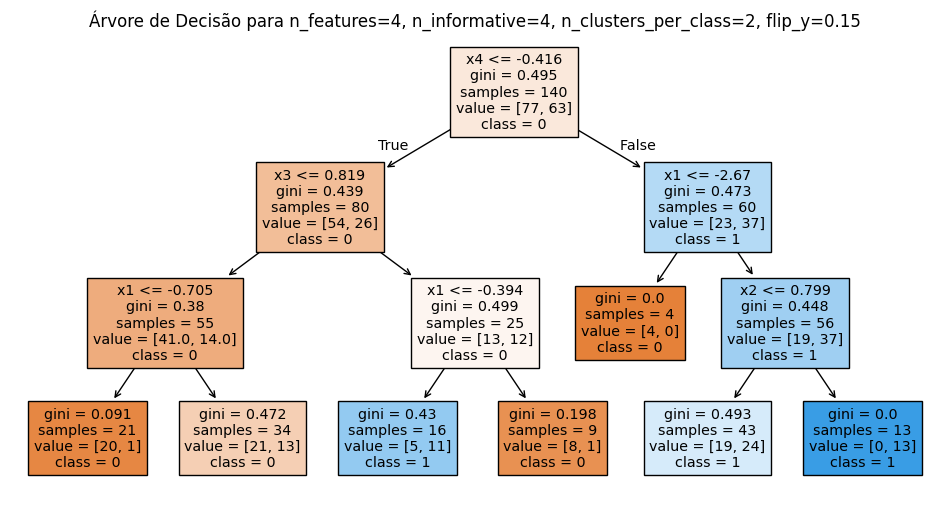

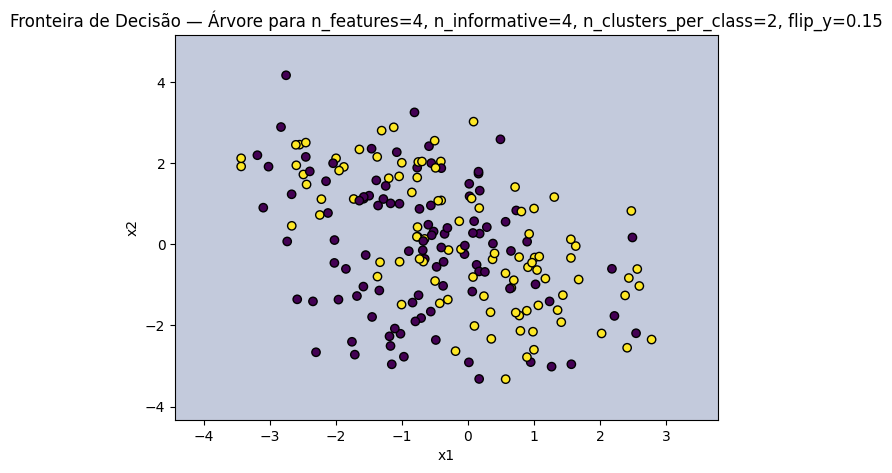

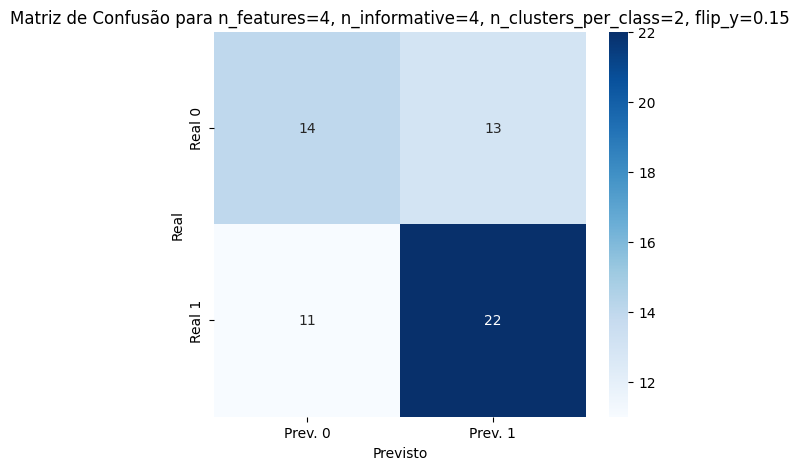

MÉTRICAS DO MODELO
Accuracy para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.15 : 0.600
Precisão para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.15 : 0.629
Recall para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.15  : 0.667
F1-score para n_features=4, n_informative=4, n_clusters_per_class=2, flip_y=0.15 : 0.647


In [18]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

f = 4 #n_features
ni = [2, 4] #n_informative
nc = [1, 2] #n_clusters_per_class
yf = [0.0, 0.15] #flip_y

feature_names = [f"x{j+1}" for j in range(f)]

for i in ni:
  for c in nc:
    for y_f in yf:

        # =====================================================
        # 1) Gerar dados simples
        # =====================================================
        X, y = make_classification(flip_y=y_f, n_samples=200, n_features=f,
                                  n_redundant=0, n_informative=i,
                                  n_clusters_per_class=c, random_state=0)

        # =====================================================
        # 2) Dividir em treino e teste
        # =====================================================
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=0
        )

        # =====================================================
        # 3) Treinar a árvore
        # =====================================================
        model = DecisionTreeClassifier(max_depth=3)
        model.fit(X_train, y_train)

        # =====================================================
        # 4) Visualizar a Árvore
        # =====================================================
        plt.figure(figsize=(12,6))
        plot_tree(model, filled=True, feature_names=feature_names, class_names=["0","1"])
        plt.title(f"Árvore de Decisão para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f}")
        plt.show()

        # =====================================================
        # 5) Fronteira de decisão
        # =====================================================
        xx, yy = np.meshgrid(
            np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
            np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
        )

        X_grid = np.zeros((xx.ravel().shape[0], f))

        X_grid[:, 0] = xx.ravel()
        X_grid[:, 1] = yy.ravel()

        # Fixa as demais features na média
        X_grid[:, 2] = X[:, 2].mean()
        X_grid[:, 3] = X[:, 3].mean()

        Z = model.predict(X_grid)
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(7,5))
        plt.contourf(xx, yy, Z, alpha=0.3)
        plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

        plt.title(f"Fronteira de Decisão — Árvore para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.show()

        # =====================================================
        # 6) Matriz de Confusão
        # =====================================================
        y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Prev. 0", "Prev. 1"],
                    yticklabels=["Real 0", "Real 1"])

        plt.title(f"Matriz de Confusão para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f}")
        plt.ylabel("Real")
        plt.xlabel("Previsto")
        plt.show()

        # =====================================================
        # 7) Métricas de avaliação
        # =====================================================
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print("MÉTRICAS DO MODELO")
        print(f"Accuracy para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f} : {acc:.3f}")
        print(f"Precisão para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f} : {prec:.3f}")
        print(f"Recall para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f}  : {rec:.3f}")
        print(f"F1-score para n_features={f}, n_informative={i}, n_clusters_per_class={c}, flip_y={y_f} : {f1:.3f}")

**Resposta:** o modelo piora mais pra valores altos dos hyperparametros, pois um n_features muito alto, especialmente se houver poucas amostras, pode levar ao overfitting, o seja o modelo decora o ruído, e com um flip_y(ruído) alto acaba piorando o treinamento, e se n_clusters_per_class for igual a 1, a classe é um agrupamento compacto, facilitando a separação linear.